In [1]:
using Revise
using PVlib

using HTTP
using JSON
using DataFrames
using Dates
using CSV
using Plots
using Statistics
using LinearAlgebra
using TimeZones
using Random
using SparseArrays

using Snopt
using SNOW
using FiniteDiff
using ForwardDiff


In [2]:
latitude = 35.95
longitude = -75.125

api_key = "E52b7mqeTWLigj2xF5Bn4n6Mm87ecm5LFFeYh4US" # from NLR
email = "jtgrasb@sandia.gov"

start_monthday=(1, 1)
end_monthday=(1, 1)

weather_data = get_meteorological_data_nsrdb(latitude, longitude, api_key, email, start_monthday, end_monthday, false)

println(weather_data[12])

WeatherSample
────────────
time               │ 2016-01-01T11:00:00-05:00
ghi                │ 315.0
dni                │ 135.0
dhi                │ 246.0
temp_air           │ 13.200000000000001
temp_dew           │ 9.9
relative_humidity  │ missing
pressure           │ 1019.0
wind_speed         │ 5.0
wind_direction     │ 177.0
albedo             │ 0.01



In [3]:
latitude = 35.95
longitude = -75.125
altitude = 0.0

api_key = "E52b7mqeTWLigj2xF5Bn4n6Mm87ecm5LFFeYh4US" # from NLR
email = "jtgrasb@sandia.gov"

start_monthday=(1, 1)
end_monthday=(1, 1)

number_of_panels = 1
surface_azimuth = 180.0
surface_tilt = latitude

# try zygote one function at a time
weather_data = get_meteorological_data_nsrdb(latitude, longitude, api_key, email, start_monthday, end_monthday, false)

# area of 0.343 m^2, 9 cells per column with 4 columns, 0.526 x 0.652 m
module_name = "Kyocera Solar KC40T [2008 (E)]" #"Canadian Solar CS5P-220M [ 2009]" 
inverter_name = "Enphase Energy Inc : M175-24-208-Sxx [208V]" #"ABB: MICRO-0.25-I-OUTD-US-208 [208V]" # 175 W is well above max power needed

pv_module = read_solar_module(module_name)
pv_inverter = read_solar_inverter(inverter_name);

In [4]:
# prescribe WEC motion in 6 degrees of freedom for 100 seconds
time = range(0, 500, 1001)
amplitude = [1.0, 0.1, 1.0, 0.2, 1.0, 0.2]
#amplitude = [0, 0, 0, 1.4, 0, 0]
period = 10 # seconds

ω = 2π / period
WEC_response = amplitude' .* sin.(ω .* time);


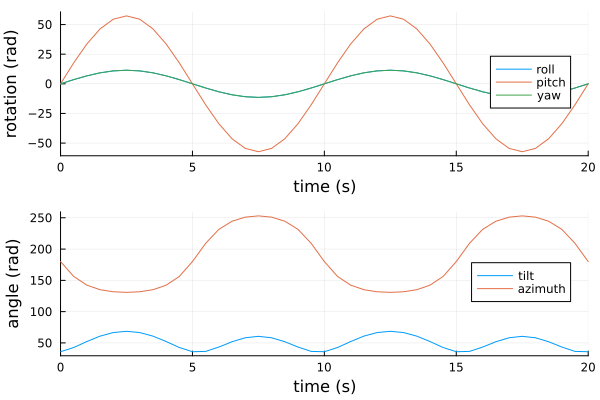

In [5]:
# translational degrees of freedom don't impact the orientation and tilt direction
installation_tilt = surface_tilt
installation_azimuth = 180.0
initial_yaw = 0.0
panel_tilt, panel_azimuth = panel_tilt_azimuth(WEC_response, installation_tilt, installation_azimuth, initial_yaw)


t = time                      # length N
x = WEC_response[:,1]; y = WEC_response[:,2]; z = WEC_response[:,3]
roll  = WEC_response[:,4]
pitch = WEC_response[:,5]
yaw   = WEC_response[:,6]

# 2) Rotational motions
p2 = plot(t, roll*180/pi,  label="roll",  xlabel="time (s)", ylabel="rotation (rad)",xlims=(0, 20),)
plot!(p2, t, pitch*180/pi, label="pitch")
plot!(p2, t, yaw*180/pi,   label="yaw")

# 3) Panel angles
p3 = plot(t, panel_tilt, label="tilt", xlabel="time (s)", ylabel="angle (rad)", xlims=(0, 20),)
plot!(p3, t, panel_azimuth,   label="azimuth")

plot(p2, p3, layout=(2,1), legend=:right)

In [6]:
# model for the albedo in ocean conditions
weather_data = get_meteorological_data_nsrdb(latitude, longitude, api_key, email, start_monthday, end_monthday, false)
sol_position = get_solar_position(latitude, longitude, altitude, weather_data[12])

# albedo from NSRDB generall not accurate over water, so use a model based on solar position and weather conditions for ocean surfaces
albedo = get_ocean_surface_albedo(weather_data[12], sol_position) 
println("Albedo: ", albedo)

#plot(getfield.(weather_data, :time), albedo, label="Albedo vs time", xlabel="time", ylabel="Albedo", legend=:topright)

Albedo: 0.06608828674260481


In [7]:
total_irradiance = get_total_irradiance(panel_tilt, panel_azimuth, weather_data[12], sol_position, albedo, time)

cell_temp_orig = sapm_cell_temperature(total_irradiance, weather_data[12]) 
cell_temp = rolling_average_sapm_cell_temperature(total_irradiance, weather_data[12]);

#plot(cell_temp_orig, :cell_temperature, label="Orig Cell Temperature")
#plot!(cell_temp, :cell_temperature, label="Rolling Average Cell Temperature")

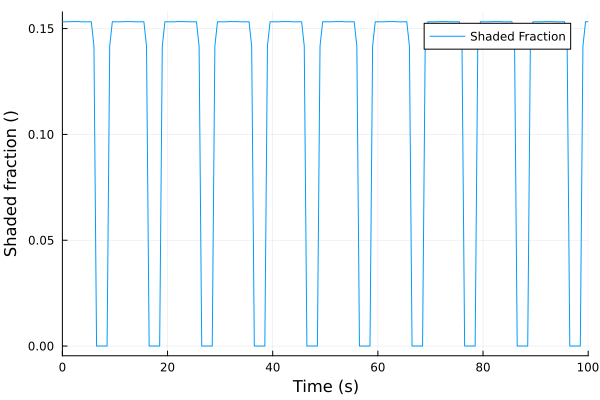

In [8]:
panel = Panel(0.526, 0.652) # panel dimensnions in meters (Kyocera Solar KC40T [2008 (E)])

# A box/beam above the panel with respect to the panel's local coordinates
obstacle = BoxObstacle(
    -1.0, 1.0,   # x-range
    -0.05, 0.05,     # y-range
    0.5, 0.6   # z-range
)

f_shade = get_shaded_fraction(sol_position, panel_tilt, panel_azimuth, panel, obstacle);

plot(time, f_shade, xlabel="Time (s)", ylabel="Shaded fraction ()", label="Shaded Fraction", legend=:topright, xlims=(0, 100))

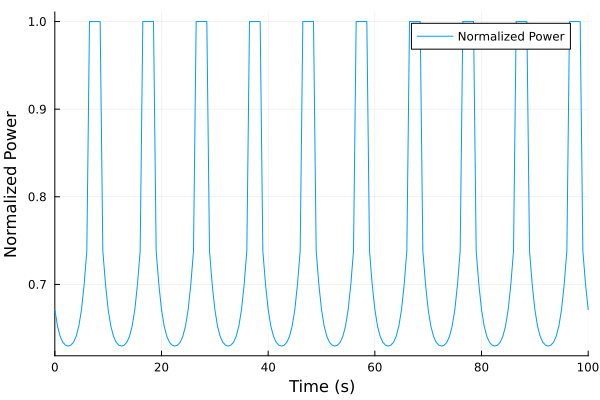

In [9]:
power_norm = get_power_norm(total_irradiance, f_shade, 9);

# Note that power normalization is approximately 1 when shaded fraction is below critical shading (1/n_cells_per_column).
plot(time, power_norm, xlabel="Time (s)", ylabel="Normalized Power", label="Normalized Power", legend=:topright, xlims=(0, 100))

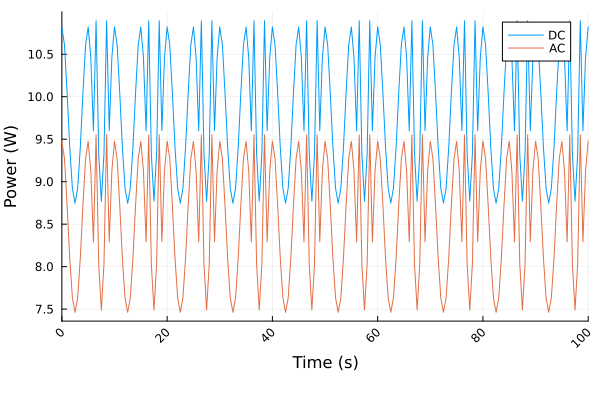

In [10]:
# assume the simulation is done for the 12th hour on this date
# in the future, we can allow time/date input to specify
sol_position = get_solar_position(latitude, longitude, altitude, weather_data[12])
total_irradiance = get_total_irradiance(panel_tilt, panel_azimuth, weather_data[12], sol_position, albedo, time)

cell_temp = rolling_average_sapm_cell_temperature(total_irradiance, weather_data[12]) 
effective_irradiance = sapm_effective_irradiance(total_irradiance, pv_module, sol_position, panel_tilt, panel_azimuth, altitude)

dc_components_shaded = sapm_dc_components_shaded(pv_module, effective_irradiance, cell_temp, power_norm)

ac_power = sandia_ac_power(pv_inverter, dc_components_shaded)

plot(dc_components_shaded, :p_mp, :elapsed, label="DC")
plot!(ac_power, :ac_power, :elapsed, label="AC", xlabel="Time (s)", ylabel="Power (W)", legend=:topright, xrotation = 45, bottom_margin=8Plots.mm, xlims=(0, 100))


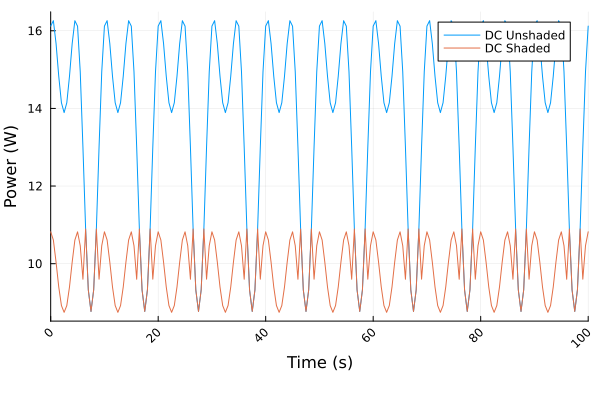

In [11]:
dc_components = sapm_dc_components(pv_module, effective_irradiance, cell_temp)

dc_components_shaded = sapm_dc_components_shaded(pv_module, effective_irradiance, cell_temp, power_norm)

plot(dc_components, :p_mp, :elapsed, label="DC Unshaded")
plot!(dc_components_shaded, :p_mp, :elapsed, label="DC Shaded", xlabel="Time (s)", ylabel="Power (W)", xrotation = 45, bottom_margin=8Plots.mm, xlims=(0, 100))
#plot!(time, 10*power_norm, label="Power normalization factor", legend=:topright, xlims=(0, 100))

In [12]:
# optimize the initial panel tilt to maximize average power using Zygote
# assume initial yaw is always the same

# create function that support initial tilt input
function dc_power_return(latitude, longitude, altitude, 
                        initial_tilt, initial_azimuth, weather_data, sol_position, 
                        pv_module, pv_inverter, WEC_response, panel, obstacle, 
                        n_cells_per_column, albedo, sim_time)
    
    panel_tilt, panel_azimuth = panel_tilt_azimuth(WEC_response, initial_tilt, initial_azimuth)

    total_irradiance = get_total_irradiance(panel_tilt, panel_azimuth, weather_data, sol_position, albedo, sim_time) 
    cell_temp = rolling_average_sapm_cell_temperature(total_irradiance, weather_data)

    effective_irradiance = sapm_effective_irradiance(total_irradiance, pv_module, sol_position, panel_tilt, panel_azimuth, altitude)

    f_shade = get_shaded_fraction(sol_position, panel_tilt, panel_azimuth, panel, obstacle, nx=10, ny=10)
    power_norm = get_power_norm(total_irradiance, f_shade, n_cells_per_column)

    dc_components_shaded = sapm_dc_components_shaded(pv_module, effective_irradiance, cell_temp, power_norm)
    ac_power = sandia_ac_power(pv_inverter, dc_components_shaded)
    return getfield.(dc_components_shaded, :p_mp)
end

dc_power_return (generic function with 1 method)

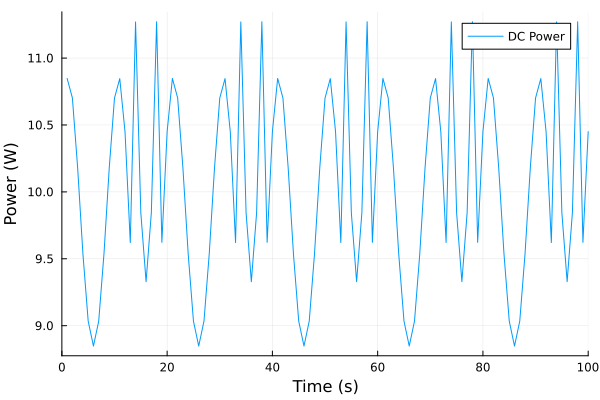

In [13]:
# location and installation details for pioneer
latitude = 35.95
longitude = -75.125
altitude = 0.0 # m
api_key = "E52b7mqeTWLigj2xF5Bn4n6Mm87ecm5LFFeYh4US" # from NLR
email = "jtgrasb@sandia.gov"
start_monthday=(1, 1)
end_monthday=(1, 1)
number_of_panels = 1
initial_azimuth = 180.0
initial_tilt = latitude
module_name = "Kyocera Solar KC40T [2008 (E)]" #"Canadian Solar CS5P-220M [ 2009]" 
inverter_name = "Enphase Energy Inc : M175-24-208-Sxx [208V]" #"ABB: MICRO-0.25-I-OUTD-US-208 [208V]" # 175 W is well above max power needed
pv_module = read_solar_module(module_name)
pv_inverter = read_solar_inverter(inverter_name);

# create example WEC resposne
time = range(0, 500, 1001)
amplitude = [1, 0.1, 1, 0.1, 1, 0.2]
period = 10 # seconds
ω = 2π / period
WEC_response = amplitude' .* sin.(ω .* time)

# installation characteristics
panel = Panel(0.526, 0.652) # panel dimensnions in meters (Kyocera Solar KC40T [2008 (E)])
# A box above the panel
obstacle = BoxObstacle(
    -0.5, 0.5,   # x-range
    -0.3, 0.3,     # y-range
    0.4, 0.5   # z-range
)
n_cells_per_column = 9

# import weather data, calculate solar position, and corresponding albedo
weather_data = get_meteorological_data_nsrdb(latitude, longitude, api_key, email, start_monthday, end_monthday, false)
weather_data = weather_data[12] # just use the 12th hour for this simulation
sol_position = get_solar_position(latitude, longitude, altitude, weather_data)
albedo = get_ocean_surface_albedo(weather_data, sol_position)

dc_power = dc_power_return(latitude, longitude, altitude, initial_tilt, initial_azimuth, weather_data, sol_position, pv_module, pv_inverter, WEC_response, panel, obstacle, n_cells_per_column, albedo, time)

plot(dc_power, label="DC Power", xlabel="Time (s)", ylabel="Power (W)", legend=:topright, xlims=(0, 100))

In [14]:
function objective(latitude, longitude, altitude, 
                        installation_tilt, installation_azimuth, weather_data, sol_position, 
                        pv_module, pv_inverter, WEC_response, panel, obstacle, 
                        n_cells_per_column, albedo, sim_time)

    avg_power = mean(dc_power_return(latitude, longitude, altitude, 
                        installation_tilt, installation_azimuth, weather_data, sol_position, 
                        pv_module, pv_inverter, WEC_response, panel, obstacle, 
                        n_cells_per_column, albedo, sim_time))
    return -avg_power
end

installation_tilt = latitude
installation_azimuth = 180.0

check_mean_power = objective(latitude, longitude, altitude, installation_tilt, installation_azimuth, weather_data, sol_position, pv_module, pv_inverter, WEC_response, panel, obstacle, n_cells_per_column, albedo, time)
println("Mean power for installation tilt: ", -check_mean_power)

mean_power = orientation -> objective(latitude, longitude, altitude, orientation[1], installation_azimuth, weather_data, sol_position, pv_module, pv_inverter, WEC_response, panel, obstacle, n_cells_per_column, albedo, time)

Mean power for installation tilt: 10.058620686889297


#2 (generic function with 1 method)

In [15]:
fd_using_fd = FiniteDiff.finite_difference_derivative(mean_power, initial_tilt, Val(:central))

-0.004523634883983512

In [16]:
ad_using_fd = ForwardDiff.derivative(mean_power, initial_tilt)

-0.004523634872684392

In [17]:
# The SNOW/SNOPT multistart below optimizes installation tilt and azimuth together.
nothing

using SNOW
println(names(SNOW, all=true))
println(propertynames(SNOW))

[Symbol("##Options#3"), Symbol("##SNOPT#7"), Symbol("##meta#60"), Symbol("#67#runtime_path"), Symbol("#Options#3"), Symbol("#SNOPT#7"), Symbol("#__init__"), Symbol("#__init__##0#__init__##1"), Symbol("#__init__##2#__init__##3"), Symbol("#__init__##4#__init__##5"), Symbol("#addOption"), Symbol("#combine!#createcache##0"), Symbol("#combine!#createcache##1"), Symbol("#combine!#createcache##2"), Symbol("#createcache"), Symbol("#eval_h#optimize##4"), Symbol("#evaluate!"), Symbol("#finitediff_type"), Symbol("#fsnopt!#optimize##5"), Symbol("#getsparsity"), Symbol("#getsparsity##0#getsparsity##1"), Symbol("#getsparsity##2#getsparsity##3"), Symbol("#gradient!"), Symbol("#gradientcache"), Symbol("#ipcon#optimize##0"), Symbol("#ipgrad_obj#optimize##2"), Symbol("#ipjac_con#optimize##3"), Symbol("#ipobj#optimize##1"), Symbol("#minimize"), Symbol("#obj#gradientcache##0"), Symbol("#optimize"), Symbol("#resizebounds"), Symbol("#sparsejacobian!"), Symbol("#sparsejacobiancache"), :AbstractDiffMethod, :A

In [18]:
# Optimize installation tilt and azimuth with SNOW/SNOPT Latin-hypercube multistart.
mean_power = orientation -> objective(latitude, longitude, altitude, orientation[1], orientation[2], weather_data, sol_position, pv_module, pv_inverter, WEC_response, panel, obstacle, n_cells_per_column, albedo, time)

lower = [0.0, 0.0]
upper = [90.0, 360.0]

function latin_hypercube(lower, upper; n_samples=10 * length(lower), rng=Random.default_rng(), centered=false)
    length(lower) == length(upper) || throw(DimensionMismatch("lower and upper must have the same length"))
    n_samples > 0 || throw(ArgumentError("n_samples must be positive"))

    n_dim = length(lower)
    samples = Matrix{Float64}(undef, n_samples, n_dim)
    for j in 1:n_dim
        lo = Float64(lower[j])
        hi = Float64(upper[j])
        isfinite(lo) && isfinite(hi) || throw(ArgumentError("Latin hypercube bounds must be finite"))
        hi >= lo || throw(ArgumentError("upper[$j] must be greater than or equal to lower[$j]"))

        width = hi - lo
        perm = randperm(rng, n_samples)
        offsets = centered ? fill(0.5, n_samples) : rand(rng, n_samples)
        for i in 1:n_samples
            unit = (perm[i] - 1 + offsets[i]) / n_samples
            samples[i, j] = lo + width * unit
        end
    end
    return samples
end

orientation_scale = upper .- lower
to_scaled_orientation(orientation) = (Float64.(orientation) .- lower) ./ orientation_scale
from_scaled_orientation(y) = lower .+ y .* orientation_scale
snopt_objective_scaled(y) = mean_power(from_scaled_orientation(y))

constraint_rows = [1, 2, 3, 4]
constraint_cols = [1, 1, 2, 2]
constraint_values = [1.0, -1.0, 1.0, -1.0]
snopt_sparsity = SNOW.SparsePattern(
    sparse(constraint_rows, constraint_cols, ones(length(constraint_rows)), 4, 2)
)

function compact_trace(trace_x; atol=1.0e-8)
    compact_x = Vector{Vector{Float64}}()
    for x in trace_x
        if isempty(compact_x) || norm(x .- compact_x[end]) > atol
            push!(compact_x, copy(x))
        end
    end
    return reduce(vcat, (permutedims(xi) for xi in compact_x))
end

function run_snopt_orientation_from_start(start, run_index; max_major_iter=100)
    y0 = clamp.(to_scaled_orientation(start), 0.0, 1.0)
    trace_x = Vector{Vector{Float64}}()
    trace_power = Float64[]

    function snopt_orientation_callback!(g, df, dg, y)
        orientation = Float64.(from_scaled_orientation(y))
        push!(trace_x, orientation)

        f = snopt_objective_scaled(y)
        push!(trace_power, -Float64(f))

        g[1] = y[1]
        g[2] = 1.0 - y[1]
        g[3] = y[2]
        g[4] = 1.0 - y[2]

        # Central differences are more robust for the merged, piecewise shading objective.
        # The bound-constraint Jacobian below is still supplied analytically as a sparse pattern.
        FiniteDiff.finite_difference_gradient!(df, snopt_objective_scaled, y, Val(:central))
        dg .= constraint_values
        return f
    end

    solver = SNOW.SNOPT(options = Dict(
        "Major iterations limit" => max_major_iter,
        "Iterations limit" => max(1000, 50 * max_major_iter),
        "Major optimality tolerance" => 1.0e-6,
        "Major feasibility tolerance" => 1.0e-6,
        "Function precision" => 1.0e-6,
        "Print file" => joinpath(tempdir(), "wec_motion_snow_snopt_run_$(run_index).out"),
        "Summary file" => joinpath(tempdir(), "wec_motion_snow_snopt_run_$(run_index).summary.out"),
        "Major print level" => 0,
        "Minor print level" => 0,
        "Print frequency" => 1,
    ))
    options = SNOW.Options(
        sparsity = snopt_sparsity,
        derivatives = SNOW.UserDeriv(),
        solver = solver,
    )

    xopt = nothing
    fopt = nothing
    status = nothing
    out = nothing
    elapsed_seconds = @elapsed begin
        xopt, fopt, status, out = SNOW.minimize(
            snopt_orientation_callback!,
            y0,
            4,
            zeros(2),
            ones(2),
            zeros(4),
            fill(Inf, 4),
            options,
        )
    end

    optimum = Float64.(from_scaled_orientation(xopt))
    push!(trace_x, optimum)
    push!(trace_power, -Float64(fopt))

    return (
        start = Float64.(start),
        minimizer = optimum,
        scaled_minimizer = xopt,
        minimum = Float64(fopt),
        maximum_power = -Float64(fopt),
        status = status,
        elapsed_seconds = elapsed_seconds,
        trace = compact_trace(trace_x),
        trace_power = trace_power,
        solver_output = out,
    )
end

rng = MersenneTwister(20260603)
seed_starts = [surface_tilt 180.0; 10.0 60.0]
lhs_starts = latin_hypercube(lower, upper; n_samples=4, rng=rng)
orientation_starts = vcat(seed_starts, lhs_starts)

println("SNOW/SNOPT Latin-hypercube multistart starts:")
for i in axes(orientation_starts, 1)
    println("start ", i, ": (", round(orientation_starts[i, 1]; digits=3), ", ", round(orientation_starts[i, 2]; digits=3), ")")
end

snopt_runs = [
    run_snopt_orientation_from_start(vec(orientation_starts[i, :]), i)
    for i in axes(orientation_starts, 1)
]

best_snopt_run_index = argmin([run.minimum for run in snopt_runs])
best_snopt_run = snopt_runs[best_snopt_run_index]

println("SNOW/SNOPT sparse-gradient optima:")
for (i, run) in enumerate(snopt_runs)
    println(
        "run ", i,
        ": status=", run.status,
        ", start=", round.(run.start; digits=3),
        " -> optimum=", round.(run.minimizer; digits=3),
        ", mean power=", round(run.maximum_power; digits=6),
        ", solve time=", round(run.elapsed_seconds; digits=3), " s",
        ", trace points=", size(run.trace, 1),
    )
end

println("Best SNOW/SNOPT run index: ", best_snopt_run_index)
println("Best SNOW/SNOPT installation tilt: ", best_snopt_run.minimizer[1])
println("Best SNOW/SNOPT installation azimuth: ", best_snopt_run.minimizer[2])
println("Best SNOW/SNOPT mean power: ", best_snopt_run.maximum_power)


SNOW/SNOPT Latin-hypercube multistart starts:
start 1: (35.95, 180.0)
start 2: (10.0, 60.0)
start 3: (75.335, 40.991)
start 4: (29.695, 126.381)
start 5: (2.903, 229.267)
start 6: (55.904, 301.449)
SNOW/SNOPT sparse-gradient optima:
run 1: status=Finished successfully: optimality conditions satisfied, start=[35.95, 180.0] -> optimum=[32.215, 159.237], mean power=10.210402, solve time=4.116 s, trace points=25
run 2: status=Finished successfully: optimality conditions satisfied, start=[10.0, 60.0] -> optimum=[9.262, 84.968], mean power=10.695708, solve time=1.358 s, trace points=17
run 3: status=Finished successfully: optimality conditions satisfied, start=[75.335, 40.991] -> optimum=[69.314, 123.036], mean power=9.265435, solve time=1.198 s, trace points=15
run 4: status=Finished successfully: optimality conditions satisfied, start=[29.695, 126.381] -> optimum=[32.28, 126.249], mean power=10.293482, solve time=2.063 s, trace points=24
run 5: status=Finished successfully: optimality cond

Saved SNOW/SNOPT multistart summary plot: c:\Users\jtgrasb\Documents\GitHub\PVlib.jl\examples\figures\wec_motion_snow_multistart_summary.png


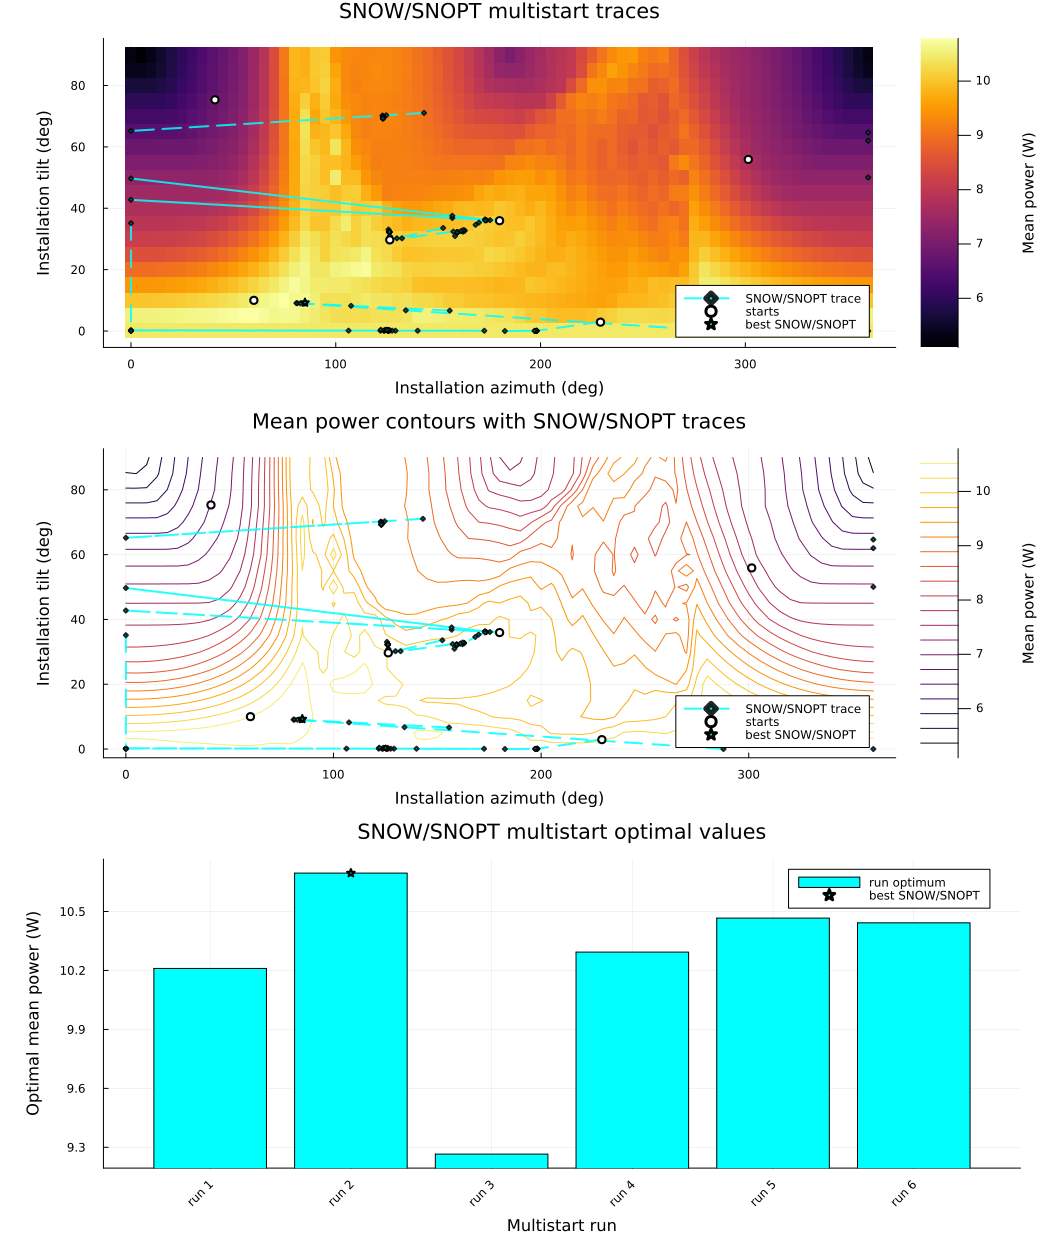

In [ ]:
tilt_range = 0.0:5.0:90.0
azimuth_range = 0.0:5.0:360.0

power_grid = [
    -objective(
        latitude, longitude, altitude,
        tilt, azimuth,
        weather_data, sol_position,
        pv_module, pv_inverter, WEC_response,
        panel, obstacle, n_cells_per_column,
        albedo, time
    )
    for tilt in tilt_range, azimuth in azimuth_range
]

function trace_with_periodic_breaks(trace; azimuth_jump_break=180.0)
    azimuth = Float64[]
    tilt = Float64[]
    for i in axes(trace, 1)
        if i > first(axes(trace, 1)) && abs(trace[i, 2] - trace[i - 1, 2]) > azimuth_jump_break
            push!(azimuth, NaN)
            push!(tilt, NaN)
        end
        push!(azimuth, trace[i, 2])
        push!(tilt, trace[i, 1])
    end
    return azimuth, tilt
end

p1 = heatmap(
    azimuth_range,
    tilt_range,
    power_grid,
    xlabel="Installation azimuth (deg)",
    ylabel="Installation tilt (deg)",
    colorbar_title="Mean power (W)",
    title="SNOW/SNOPT multistart traces",
    legend=:bottomright,
)

for (i, run) in enumerate(snopt_runs)
    if size(run.trace, 1) > 1
        trace_azimuth, trace_tilt = trace_with_periodic_breaks(run.trace)
        plot!(p1, trace_azimuth, trace_tilt, linewidth=2, linestyle=:dash, marker=:diamond, markersize=2,
              color=:cyan, linealpha=0.85, markeralpha=0.85,
              label=i == 1 ? "SNOW/SNOPT trace" : "")
    end
end
scatter!(p1, orientation_starts[:, 2], orientation_starts[:, 1], color=:white, markerstrokecolor=:black, label="starts")
scatter!(p1, [best_snopt_run.minimizer[2]], [best_snopt_run.minimizer[1]], color=:cyan, marker=:star5, markerstrokecolor=:black, label="best SNOW/SNOPT")

p2 = contour(
    azimuth_range,
    tilt_range,
    power_grid,
    xlabel="Installation azimuth (deg)",
    ylabel="Installation tilt (deg)",
    title="Mean power contours with SNOW/SNOPT traces",
    levels=20,
    colorbar_title="Mean power (W)",
    legend=:bottomright,
)

for (i, run) in enumerate(snopt_runs)
    if size(run.trace, 1) > 1
        trace_azimuth, trace_tilt = trace_with_periodic_breaks(run.trace)
        plot!(p2, trace_azimuth, trace_tilt, linewidth=2, linestyle=:dash, marker=:diamond, markersize=2,
              color=:cyan, linealpha=0.85, markeralpha=0.85,
              label=i == 1 ? "SNOW/SNOPT trace" : "")
    end
end
scatter!(p2, orientation_starts[:, 2], orientation_starts[:, 1], color=:white, markerstrokecolor=:black, label="starts")
scatter!(p2, [best_snopt_run.minimizer[2]], [best_snopt_run.minimizer[1]], color=:cyan, marker=:star5, markerstrokecolor=:black, label="best SNOW/SNOPT")

run_indices = collect(1:length(snopt_runs))
run_powers = [run.maximum_power for run in snopt_runs]
power_span = maximum(run_powers) - minimum(run_powers)
power_margin = max(0.02, 0.05 * power_span)
p3 = bar(
    run_indices,
    run_powers,
    xlabel="Multistart run",
    ylabel="Optimal mean power (W)",
    title="SNOW/SNOPT multistart optimal values",
    legend=:topright,
    xticks=(run_indices, string.("run ", run_indices)),
    xrotation=45,
    ylims=(minimum(run_powers) - power_margin, maximum(run_powers) + power_margin),
    color=:cyan,
    label="run optimum",
)
scatter!(p3, [best_snopt_run_index], [best_snopt_run.maximum_power], color=:cyan, marker=:star5, markerstrokecolor=:black, label="best SNOW/SNOPT")

summary_plot = plot(p1, p2, p3, layout=(3, 1), size=(1050, 1250), left_margin=10Plots.mm)
figures_dir = isdir(joinpath(pwd(), "examples", "figures")) ? joinpath(pwd(), "examples", "figures") : joinpath(pwd(), "figures")
mkpath(figures_dir)
summary_plot_path = joinpath(figures_dir, "wec_motion_snow_multistart_summary.png")
#savefig(summary_plot, summary_plot_path)
println("Saved SNOW/SNOPT multistart summary plot: ", summary_plot_path)
summary_plot


In [20]:
# Reverse-mode Zygote is not used for this SNOW/SNOPT workflow.
nothing
